<a href="https://colab.research.google.com/github/Bharath-Mani/ML-II-LAB/blob/main/ML_II_Lab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import math
import matplotlib.pyplot as plt

data = [
    {"Outlook": "Sunny",  "Humidity": "High",   "Play": "No"},
    {"Outlook": "Sunny",  "Humidity": "Normal", "Play": "No"},
    {"Outlook": "Rainy",  "Humidity": "High",   "Play": "No"},
    {"Outlook": "Rainy",  "Humidity": "Normal", "Play": "Yes"},
    {"Outlook": "Cloudy", "Humidity": "High",   "Play": "No"},
    {"Outlook": "Cloudy", "Humidity": "Normal", "Play": "Yes"},
    {"Outlook": "Windy",  "Humidity": "Normal", "Play": "No"}
]

In [13]:
def generate_rules(data):
    rules = []

    for row in data:
        if row["Play"] == "Yes":
            rule = (
                f"IF Outlook = {row['Outlook']} "
                f"AND Humidity = {row['Humidity']} "
                f"THEN Play = Yes"
            )

            if rule not in rules:
                rules.append(rule)

    return rules


print("RIPPER/CN2 STYLE RULES")
print("----------------------")

rules = generate_rules(data)

for rule in rules:
    print(rule)

RIPPER/CN2 STYLE RULES
----------------------
IF Outlook = Rainy AND Humidity = Normal THEN Play = Yes
IF Outlook = Cloudy AND Humidity = Normal THEN Play = Yes


In [14]:
positive = [
    ("Sunny", "Normal"),
    ("Rainy", "Normal"),
    ("Cloudy", "High"),
    ("Cloudy", "Normal"),
    ("Sunny", "High")
]

negative = [
    ("Rainy", "High"),
    ("Windy", "Normal")
]

def foil_gain(p0, n0, p1, n1):

    if p1 == 0:
        return 0

    if n1 == 0:
        return p1 * (
            math.log2(p1 / p1) -
            math.log2(p0 / (p0 + n0))
        )

    return p1 * (
        math.log2(p1 / (p1 + n1)) -
        math.log2(p0 / (p0 + n0))
    )

In [15]:
conditions = [
    ("Humidity", "Normal"),
    ("Humidity", "High"),
    ("Outlook", "Sunny"),
    ("Outlook", "Rainy"),
    ("Outlook", "Cloudy"),
    ("Outlook", "Windy")
]

gains = []

p0 = len(positive)
n0 = len(negative)

for attribute, value in conditions:

    p1 = 0
    n1 = 0

    for outlook, humidity in positive:
        if attribute == "Outlook" and outlook == value:
            p1 += 1
        elif attribute == "Humidity" and humidity == value:
            p1 += 1

    for outlook, humidity in negative:
        if attribute == "Outlook" and outlook == value:
            n1 += 1
        elif attribute == "Humidity" and humidity == value:
            n1 += 1

    gain = foil_gain(p0, n0, p1, n1)
    gains.append(gain)

    print(
        f"{attribute} = {value} -> "
        f"FOIL Gain = {gain:.3f}"
    )


best_index = gains.index(max(gains))
best_condition = conditions[best_index]

print("\nBEST FOIL RULE")
print("--------------")
print(
    f"IF {best_condition[0]} = {best_condition[1]} "
    f"THEN Play = Yes"
)

Humidity = Normal -> FOIL Gain = 0.211
Humidity = High -> FOIL Gain = -0.199
Outlook = Sunny -> FOIL Gain = 0.971
Outlook = Rainy -> FOIL Gain = -0.515
Outlook = Cloudy -> FOIL Gain = 0.971
Outlook = Windy -> FOIL Gain = 0.000

BEST FOIL RULE
--------------
IF Outlook = Sunny THEN Play = Yes


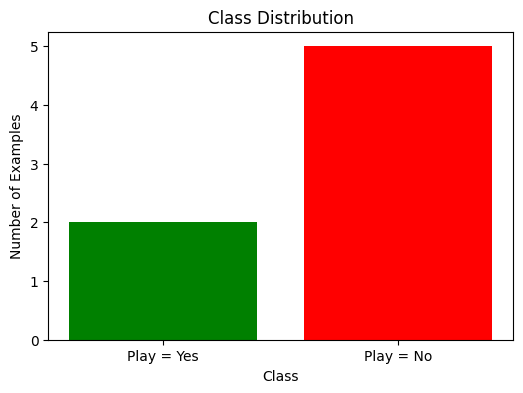

In [16]:
yes_count = sum(1 for row in data if row["Play"] == "Yes")
no_count = sum(1 for row in data if row["Play"] == "No")

plt.figure(figsize=(6, 4))

plt.bar(
    ["Play = Yes", "Play = No"],
    [yes_count, no_count],
    color=["green", "red"]
)

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Examples")

plt.show()

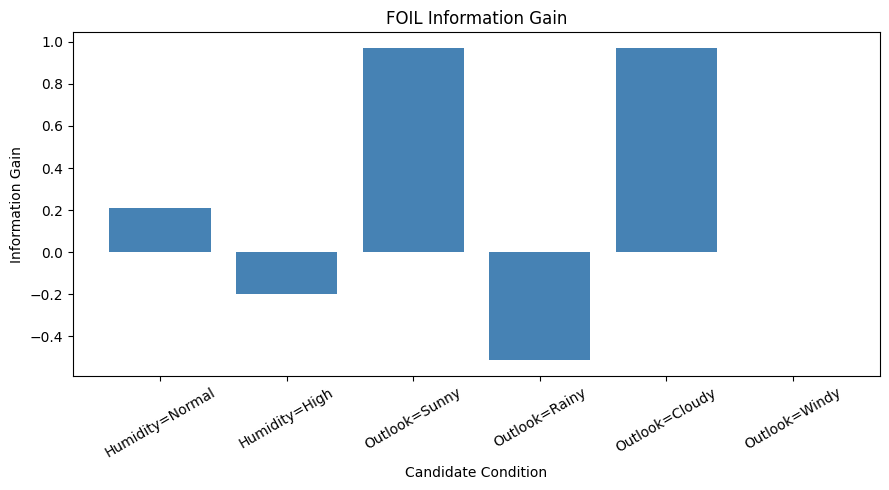

In [17]:
labels = [
    f"{a}={v}"
    for a, v in conditions
]

plt.figure(figsize=(9, 5))

plt.bar(
    labels,
    gains,
    color="steelblue"
)

plt.title("FOIL Information Gain")
plt.xlabel("Candidate Condition")
plt.ylabel("Information Gain")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()